In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import sys
import time
import json
import numpy as np
import pandas as pd
import geopandas as gpd
import pickle as pkl
import networkx as nx
import matplotlib.pyplot as plt

import good
from good.reload import deep_reload

This nodebook shows an example of how to run GOOD for a pre-build graph. In this case the WECC example graph is loaded and run for 7 days with results plotted. The same is done with flexible base loads in the second example.

The first step is to load the graph. Let's use the WECC example.

In [2]:
graph = good.graph.graph_from_json('Examples/WEC.json')

graph.nodes

NodeView(('WECC_AZ', 'WECC_CO', 'WECC_ID', 'WECC_IID', 'WECC_MT', 'WECC_NM', 'WECC_NNV', 'WECC_PNW', 'WECC_SCE', 'WECC_SNV', 'WECC_UT', 'WECC_WY', 'WEC_BANC', 'WEC_CALN', 'WEC_LADW', 'WEC_SDGE'))

Let's make this sepcific to California by making a subgraph

In [3]:
graph = good.graph.subgraph(graph, [n for n in graph.nodes if 'WEC_' in n])

First we will consider the current grid with no capacity expanison and no load shifting.

We will also not apply RPS constraints

In [4]:
'''
Loading graph and policies - with no capex
'''
deep_reload(good)

graph = good.graph.graph_from_json('Examples/WEC.json')

graph = good.graph.subgraph(graph, [n for n in graph.nodes if 'WEC_' in n])

policies = good.utilities.read_json('Examples/RPS.json')

for source, node in graph._node.items():
    for asset in node.get('assets', []):

        asset['capex_capacity'] = 0

        if asset['_class'] == 'Store':

            asset['capex_capacity'] = np.inf
            asset['capex_cost'] = 1e3


In [5]:
'''
Building from graph
'''
deep_reload(good)

kw = {
    'verbose': True,
    'steps': (6 * 32 * 24, 6 * 32 * 24 + 24 * 7),
    'shortfall_capacity': np.inf,
    'shortfall_cost': 1e3,
    'wastage_capacity': np.inf,
    'wastage_cost': 1e3,
}

network = good.optimization.network.Network(**kw).from_graph(graph)

'''
Building the model
'''

network.build()

network.size()

Parameters Built: 0.14954233169555664
Variables Built: 0.1788320541381836
Constraints Built: 0.9779999256134033
Objective Built: 0.19115304946899414


ModelSizeReport(activated = Bunch(binary_variables = 0, constraints = 88368, continuous_variables = 32763, disjunctions = 0, disjuncts = 0, integer_variables = 0, nonlinear_constraints = 0, variables = 32763), overall = Bunch(binary_variables = 0, constraints = 88368, continuous_variables = 32763, disjunctions = 0, disjuncts = 0, integer_variables = 0, nonlinear_constraints = 0, variables = 32763), warning = Bunch(unassociated_disjuncts = 0))

In [6]:
'''
Solving the model
'''
deep_reload(good)

kw = {
    'solver': {
        '_name': 'cbc',
    },
}

network.solve(**kw)
results = network.results

Problem Solved: 3.0199549198150635
Results Collected: 0.8081581592559814


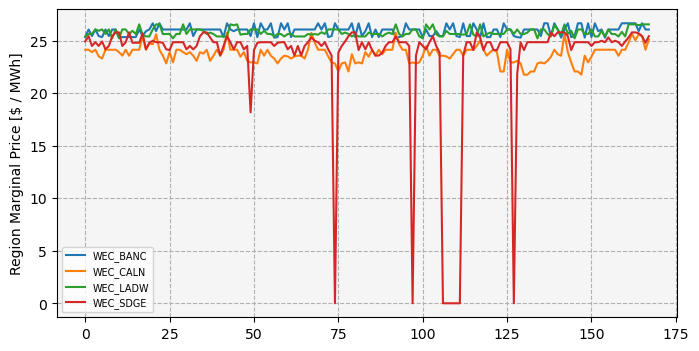

In [7]:
fig, ax = plt.subplots(1, 1, figsize = (8, 4))

for source, node in graph._node.items():

    ax.plot(
        np.array(results[source]['clearing_price']) * 3.6e9,
        label = source,
    )

kw = {
    'facecolor': 'whitesmoke',
    'ylabel': 'Region Marginal Price [$ / MWh]',
}

ax.set(**kw)

kw = {
    'ls': '--',
}

ax.grid(**kw)

kw = {
    'fontsize': 'x-small',
}

ax.legend(**kw)

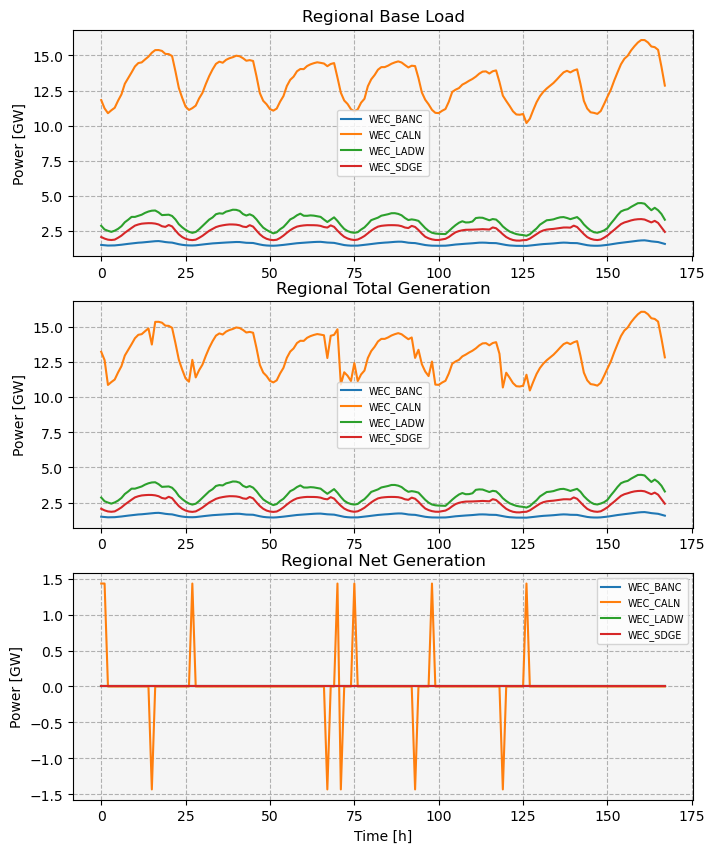

In [8]:
fig, ax = plt.subplots(3, 1, figsize = (8, 10))

for source, node in graph._node.items():

    ax[0].plot(
        -np.array(results[source]['assets'][f"base_load_{source}"]['net']) / 1e9,
        label = source,
    )
    
    ax[0].set_title('Regional Base Load')

for source, node in graph._node.items():

    values = np.vstack(
        [v["net"] for k, v in results[source]['assets'].items() if "base" not in k]
    )

    ax[1].plot(
        values.sum(axis = 0) / 1e9,
        label = source,
    )

    ax[1].set_title('Regional Total Generation')

for source, node in graph._node.items():

    values = np.vstack(
        [v["net"] for k, v in results[source]['assets'].items()]
    )

    ax[2].plot(
        values.sum(axis = 0) / 1e9,
        label = source,
    )

    ax[2].set_title('Regional Net Generation')
    ax[2].set_xlabel('Time [h]')

kw = {
    'facecolor': 'whitesmoke',
    'ylabel': 'Power [GW]',
}

_ = [ax.set(**kw) for ax in ax]

kw = {
    'ls': '--',
}

_ = [ax.grid(**kw) for ax in ax]

kw = {
    'fontsize': 'x-small',
}

_ = [ax.legend(**kw) for ax in ax]

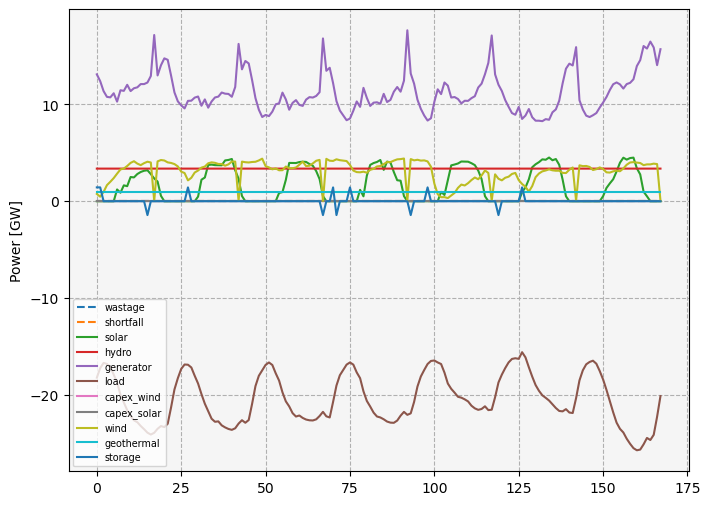

In [9]:
gen_amounts = {'wastage': [], 'shortfall': []}

for source, node in graph._node.items():

    gen_amounts['wastage'].append(network.results[source]['wastage'])
    gen_amounts['shortfall'].append(network.results[source]['shortfall'])

for source, node in graph._node.items():

    for asset in node['assets']:

        if asset['type'] not in gen_amounts:

            gen_amounts[asset['type']] = (
                [network.results[source]['assets'][asset['id']]['net']]
            )

        else:

            gen_amounts[asset['type']].append(
                [network.results[source]['assets'][asset['id']]['net']]
            )
            

for key, val in gen_amounts.items():

    gen_amounts[key] = np.vstack(val).sum(axis = 0) / 1e9

fig, ax = plt.subplots(figsize = (8, 6))

for key, val in gen_amounts.items():

    ax.plot(
        val,
        label = key,
        ls = '--' if key in ['wastage', 'shortfall'] else None,
    )

kw = {
    'facecolor': 'whitesmoke',
    'ylabel': 'Power [GW]',
}

_ = ax.set(**kw)

kw = {
    'ls': '--',
}

_ = ax.grid(**kw)

kw = {
    'fontsize': 'x-small',
}

_ = ax.legend(**kw)

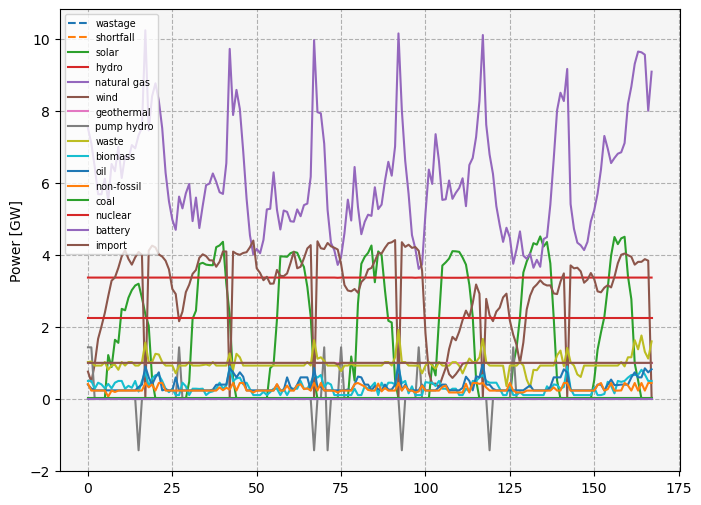

In [10]:
gen_amounts = {'wastage': [], 'shortfall': []}

for source, node in graph._node.items():

    gen_amounts['wastage'].append(network.results[source]['wastage'])
    gen_amounts['shortfall'].append(network.results[source]['shortfall'])

for source, node in graph._node.items():

    for asset in node['assets']:

        if 'fuel' not in asset:

            continue

        if asset['fuel'] not in gen_amounts:

            gen_amounts[asset['fuel']] = (
                [network.results[source]['assets'][asset['id']]['net']]
            )

        else:

            gen_amounts[asset['fuel']].append(
                [network.results[source]['assets'][asset['id']]['net']]
            )

for key, val in gen_amounts.items():

    gen_amounts[key] = np.vstack(val).sum(axis = 0) / 1e9

fig, ax = plt.subplots(figsize = (8, 6))

for key, val in gen_amounts.items():

    ax.plot(
        val,
        label = key,
        ls = '--' if key in ['wastage', 'shortfall'] else None,
    )

kw = {
    'facecolor': 'whitesmoke',
    'ylabel': 'Power [GW]',
}

_ = ax.set(**kw)

kw = {
    'ls': '--',
}

_ = ax.grid(**kw)

kw = {
    'fontsize': 'x-small',
}

_ = ax.legend(**kw)

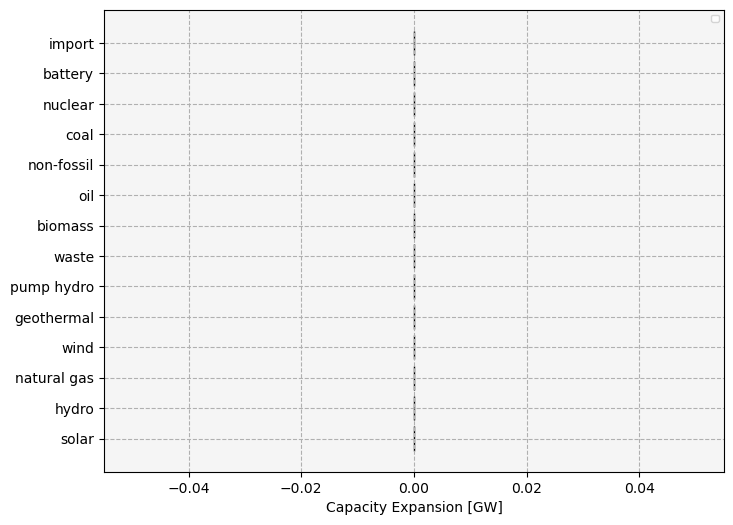

In [11]:
capex_amounts = {}

for source, node in graph._node.items():

    for asset in node['assets']:

        if 'fuel' not in asset:

            continue

        if asset['fuel'] not in capex_amounts:

            capex_amounts[asset['fuel']] = (
                [network.results[source]['assets'][asset['id']]['capex']]
            )

        else:

            capex_amounts[asset['fuel']].append(
                [network.results[source]['assets'][asset['id']]['capex']]
            )

for key, val in capex_amounts.items():

    capex_amounts[key] = np.vstack(val).sum(axis = 0)[0] / 1e6

fig, ax = plt.subplots(figsize = (8, 6))

kw = {
    'color': 'xkcd:seafoam',
    'ec': 'k',
}

ax.barh(list(capex_amounts.keys()), list(capex_amounts.values()), **kw)

kw = {
    'facecolor': 'whitesmoke',
    'xlabel': 'Capacity Expansion [GW]',
}

_ = ax.set(**kw)

kw = {
    'ls': '--',
}

_ = ax.grid(**kw)

kw = {
    'fontsize': 'x-small',
}

_ = ax.legend(**kw)

Next we will consider the current grid with allowed capacity expanison and no load shifting.

In [156]:
'''
Loading graph and policies
'''
deep_reload(good)

graph = good.graph.graph_from_json('Examples/WEC.json')

graph = good.graph.subgraph(graph, [n for n in graph.nodes if 'WEC_' in n])

policies = good.utilities.read_json('Examples/RPS.json')

for source, node in graph._node.items():
    for asset in node.get('assets', []):

        asset['capex_cost'] /= (52 * 5)

        if asset['_class'] == 'Store':

            asset['capex_capacity'] = 1e10
            asset['capex_cost'] = 1e3 / (52 * 5) * 0
            asset['ramp_rate'] = .1

In [157]:
'''
Building from graph
'''
deep_reload(good)

kw = {
    'verbose': True,
    'steps': (6 * 32 * 24, 6 * 32 * 24 + 24 * 7),
    'shortfall_capacity': np.inf,
    'shortfall_cost': 1e3,
    'wastage_capacity': np.inf,
    'wastage_cost': 1e3,
}

network = good.optimization.network.Network(**kw).from_graph(graph, policies = policies)

'''
Building the model
'''

network.build()

network.size()

Parameters Built: 0.12884998321533203
Variables Built: 0.10876989364624023
Constraints Built: 1.9754221439361572
Objective Built: 0.0866537094116211


ModelSizeReport(activated = Bunch(binary_variables = 0, constraints = 88381, continuous_variables = 32868, disjunctions = 0, disjuncts = 0, integer_variables = 0, nonlinear_constraints = 0, variables = 32868), overall = Bunch(binary_variables = 0, constraints = 88381, continuous_variables = 32868, disjunctions = 0, disjuncts = 0, integer_variables = 0, nonlinear_constraints = 0, variables = 32868), warning = Bunch(unassociated_disjuncts = 0))

In [158]:
'''
Solving the model
'''
deep_reload(good)

kw = {
    'solver': {
        '_name': 'cbc',
    },
}

network.solve(**kw)
results = network.results

Problem Solved: 4.80191707611084
Results Collected: 0.8932285308837891


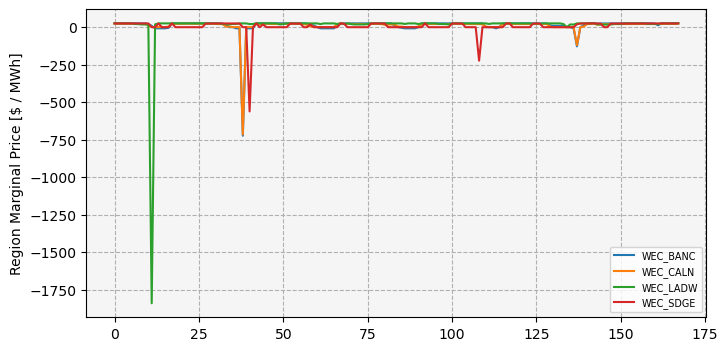

In [159]:
fig, ax = plt.subplots(1, 1, figsize = (8, 4))

for source, node in graph._node.items():

    ax.plot(
        np.array(results[source]['clearing_price']) * 3.6e9,
        label = source,
    )

kw = {
    'facecolor': 'whitesmoke',
    'ylabel': 'Region Marginal Price [$ / MWh]',
}

ax.set(**kw)

kw = {
    'ls': '--',
}

ax.grid(**kw)

kw = {
    'fontsize': 'x-small',
}

ax.legend(**kw)

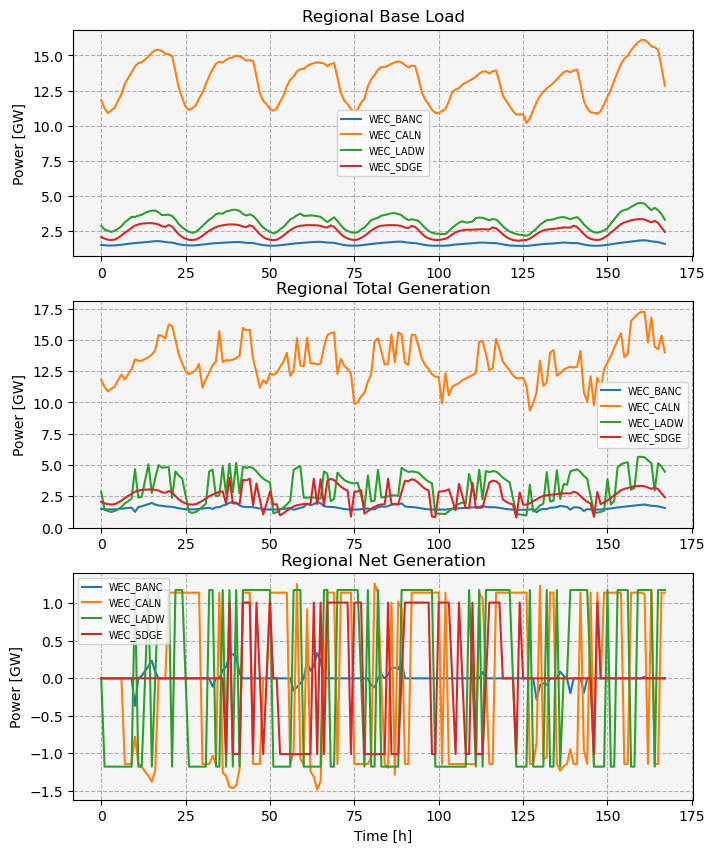

In [160]:
fig, ax = plt.subplots(3, 1, figsize = (8, 10))

for source, node in graph._node.items():

    ax[0].plot(
        -np.array(results[source]['assets'][f"base_load_{source}"]['net']) / 1e9,
        label = source,
    )
    
    ax[0].set_title('Regional Base Load')

for source, node in graph._node.items():

    values = np.vstack(
        [v["net"] for k, v in results[source]['assets'].items() if "base" not in k]
    )

    ax[1].plot(
        values.sum(axis = 0) / 1e9,
        label = source,
    )

    ax[1].set_title('Regional Total Generation')

for source, node in graph._node.items():

    values = np.vstack(
        [v["net"] for k, v in results[source]['assets'].items()]
    )

    ax[2].plot(
        values.sum(axis = 0) / 1e9,
        label = source,
    )

    ax[2].set_title('Regional Net Generation')
    ax[2].set_xlabel('Time [h]')

kw = {
    'facecolor': 'whitesmoke',
    'ylabel': 'Power [GW]',
}

_ = [ax.set(**kw) for ax in ax]

kw = {
    'ls': '--',
}

_ = [ax.grid(**kw) for ax in ax]

kw = {
    'fontsize': 'x-small',
}

_ = [ax.legend(**kw) for ax in ax]

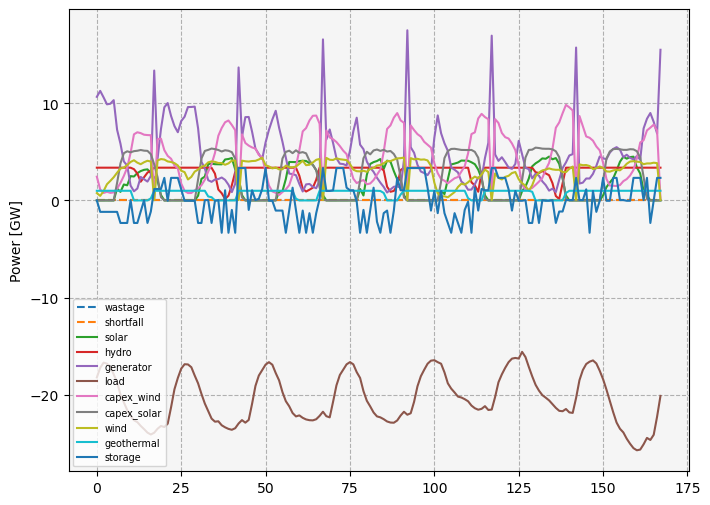

In [161]:
gen_amounts = {'wastage': [], 'shortfall': []}

for source, node in graph._node.items():

    gen_amounts['wastage'].append(network.results[source]['wastage'])
    gen_amounts['shortfall'].append(network.results[source]['shortfall'])

for source, node in graph._node.items():

    for asset in node['assets']:

        if asset['type'] not in gen_amounts:

            gen_amounts[asset['type']] = (
                [network.results[source]['assets'][asset['id']]['net']]
            )

        else:

            gen_amounts[asset['type']].append(
                [network.results[source]['assets'][asset['id']]['net']]
            )
            

for key, val in gen_amounts.items():

    gen_amounts[key] = np.vstack(val).sum(axis = 0) / 1e9

fig, ax = plt.subplots(figsize = (8, 6))

for key, val in gen_amounts.items():

    ax.plot(
        val,
        label = key,
        ls = '--' if key in ['wastage', 'shortfall'] else None,
    )

kw = {
    'facecolor': 'whitesmoke',
    'ylabel': 'Power [GW]',
}

_ = ax.set(**kw)

kw = {
    'ls': '--',
}

_ = ax.grid(**kw)

kw = {
    'fontsize': 'x-small',
}

_ = ax.legend(**kw)

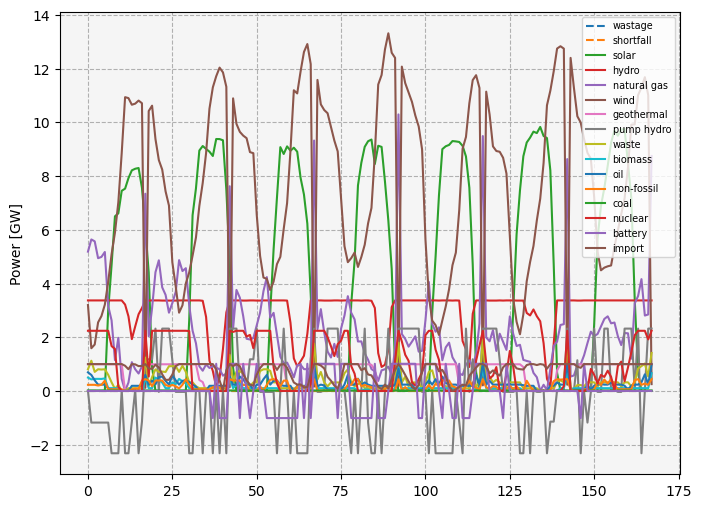

In [162]:
gen_amounts = {'wastage': [], 'shortfall': []}

for source, node in graph._node.items():

    gen_amounts['wastage'].append(network.results[source]['wastage'])
    gen_amounts['shortfall'].append(network.results[source]['shortfall'])

for source, node in graph._node.items():

    for asset in node['assets']:

        if 'fuel' not in asset:

            continue

        if asset['fuel'] not in gen_amounts:

            gen_amounts[asset['fuel']] = (
                [network.results[source]['assets'][asset['id']]['net']]
            )

        else:

            gen_amounts[asset['fuel']].append(
                [network.results[source]['assets'][asset['id']]['net']]
            )

for key, val in gen_amounts.items():

    gen_amounts[key] = np.vstack(val).sum(axis = 0) / 1e9

fig, ax = plt.subplots(figsize = (8, 6))

for key, val in gen_amounts.items():

    ax.plot(
        val,
        label = key,
        ls = '--' if key in ['wastage', 'shortfall'] else None,
    )

kw = {
    'facecolor': 'whitesmoke',
    'ylabel': 'Power [GW]',
}

_ = ax.set(**kw)

kw = {
    'ls': '--',
}

_ = ax.grid(**kw)

kw = {
    'fontsize': 'x-small',
}

_ = ax.legend(**kw)

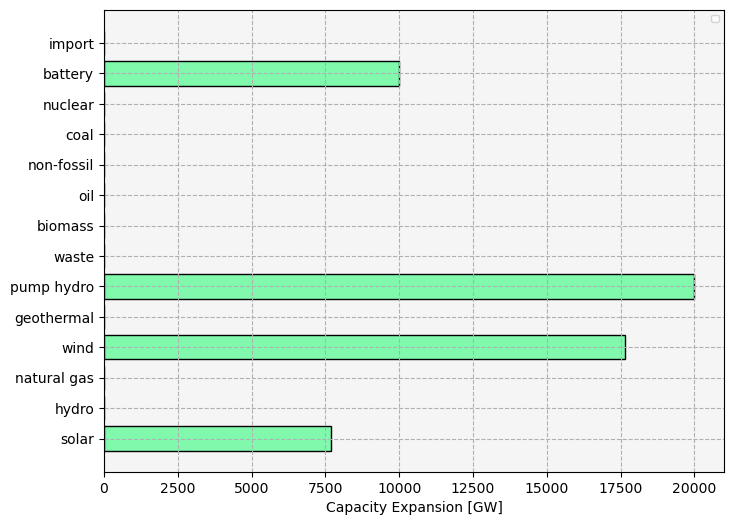

In [163]:
capex_amounts = {}

for source, node in graph._node.items():

    for asset in node['assets']:

        if 'fuel' not in asset:

            continue

        if asset['fuel'] not in capex_amounts:

            capex_amounts[asset['fuel']] = (
                [network.results[source]['assets'][asset['id']]['capex']]
            )

        else:

            capex_amounts[asset['fuel']].append(
                [network.results[source]['assets'][asset['id']]['capex']]
            )

for key, val in capex_amounts.items():

    capex_amounts[key] = np.vstack(val).sum(axis = 0)[0] / 1e6

fig, ax = plt.subplots(figsize = (8, 6))

kw = {
    'color': 'xkcd:seafoam',
    'ec': 'k',
}

ax.barh(list(capex_amounts.keys()), list(capex_amounts.values()), **kw)

kw = {
    'facecolor': 'whitesmoke',
    'xlabel': 'Capacity Expansion [GW]',
}

_ = ax.set(**kw)

kw = {
    'ls': '--',
}

_ = ax.grid(**kw)

kw = {
    'fontsize': 'x-small',
}

_ = ax.legend(**kw)

Finally we will consider the current grid with allowed capacity expanison and allowed load shifting.

In [18]:
'''
Loading graph and policies - with shifable base load
'''
deep_reload(good)

graph = good.graph.graph_from_json('Examples/WEC.json')

graph = good.graph.subgraph(graph, [n for n in graph.nodes if 'WEC_' in n])

policies = good.utilities.read_json('Examples/RPS.json')

for source, node in graph._node.items():
    for asset in node.get('assets', []):
        
        if asset['type'] == 'load':

            asset['shift_portion'] = .1
            asset['capex_cost'] /= (52 * 5)

In [19]:
'''
Building from graph
'''
deep_reload(good)

kw = {
    'verbose': True,
    'steps': (6 * 32 * 24, 6 * 32 * 24 + 24 * 7),
    'shortfall_capacity': np.inf,
    'shortfall_cost': 1e3,
    'wastage_capacity': np.inf,
    'wastage_cost': 1e3,
}

network = good.optimization.network.Network(**kw).from_graph(graph, policies = policies)

'''
Building the model
'''

network.build()

network.size()

Parameters Built: 0.13080406188964844
Variables Built: 0.11020469665527344
Constraints Built: 1.4778366088867188
Objective Built: 0.24480271339416504


ModelSizeReport(activated = Bunch(binary_variables = 0, constraints = 89045, continuous_variables = 33537, disjunctions = 0, disjuncts = 0, integer_variables = 0, nonlinear_constraints = 0, variables = 33537), overall = Bunch(binary_variables = 0, constraints = 89045, continuous_variables = 33537, disjunctions = 0, disjuncts = 0, integer_variables = 0, nonlinear_constraints = 0, variables = 33537), warning = Bunch(unassociated_disjuncts = 0))

In [20]:
'''
Solving the model
'''
deep_reload(good)

kw = {
    'solver': {
        '_name': 'cbc',
    },
}

network.solve(**kw)
results = network.results

Problem Solved: 1.72456955909729
Results Collected: 0.8050398826599121


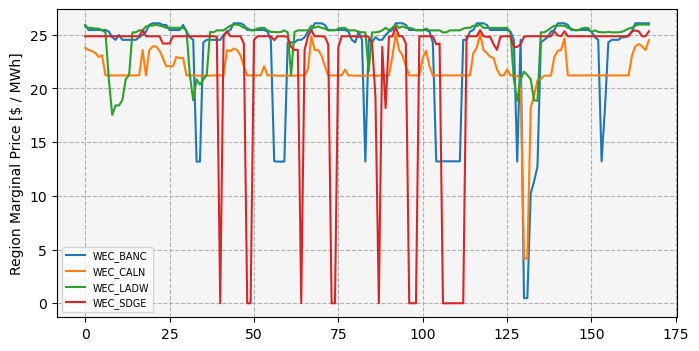

In [21]:
fig, ax = plt.subplots(1, 1, figsize = (8, 4))

for source, node in graph._node.items():

    ax.plot(
        np.array(results[source]['clearing_price']) * 3.6e9,
        label = source,
    )

kw = {
    'facecolor': 'whitesmoke',
    'ylabel': 'Region Marginal Price [$ / MWh]',
}

ax.set(**kw)

kw = {
    'ls': '--',
}

ax.grid(**kw)

kw = {
    'fontsize': 'x-small',
}

ax.legend(**kw)

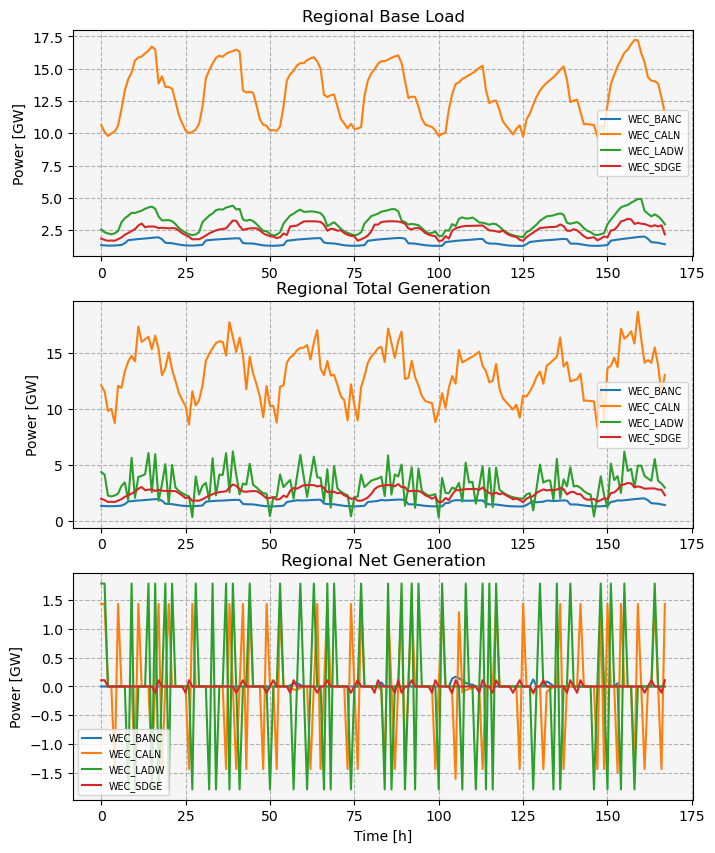

In [22]:
fig, ax = plt.subplots(3, 1, figsize = (8, 10))

for source, node in graph._node.items():

    ax[0].plot(
        -np.array(results[source]['assets'][f"base_load_{source}"]['net']) / 1e9,
        label = source,
    )
    
    ax[0].set_title('Regional Base Load')

for source, node in graph._node.items():

    values = np.vstack(
        [v["net"] for k, v in results[source]['assets'].items() if "base" not in k]
    )

    ax[1].plot(
        values.sum(axis = 0) / 1e9,
        label = source,
    )

    ax[1].set_title('Regional Total Generation')

for source, node in graph._node.items():

    values = np.vstack(
        [v["net"] for k, v in results[source]['assets'].items()]
    )

    ax[2].plot(
        values.sum(axis = 0) / 1e9,
        label = source,
    )

    ax[2].set_title('Regional Net Generation')
    ax[2].set_xlabel('Time [h]')

kw = {
    'facecolor': 'whitesmoke',
    'ylabel': 'Power [GW]',
}

_ = [ax.set(**kw) for ax in ax]

kw = {
    'ls': '--',
}

_ = [ax.grid(**kw) for ax in ax]

kw = {
    'fontsize': 'x-small',
}

_ = [ax.legend(**kw) for ax in ax]

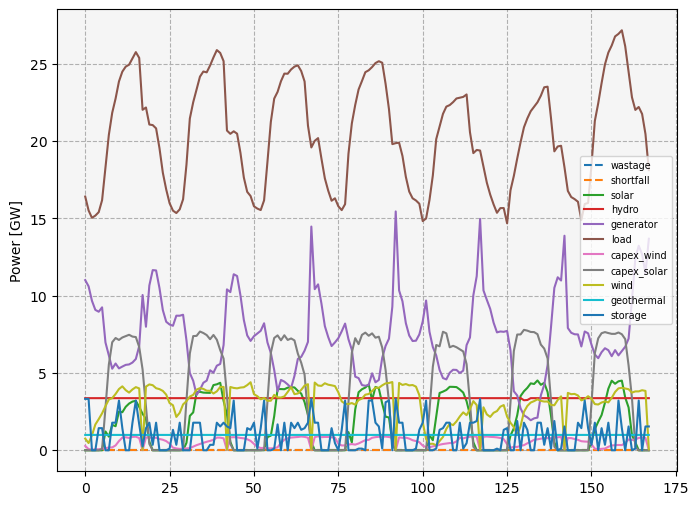

In [23]:
gen_amounts = {'wastage': [], 'shortfall': []}

for source, node in graph._node.items():

    gen_amounts['wastage'].append(network.results[source]['wastage'])
    gen_amounts['shortfall'].append(network.results[source]['shortfall'])

for source, node in graph._node.items():

    for asset in node['assets']:

        if asset['type'] not in gen_amounts:

            gen_amounts[asset['type']] = (
                [network.results[source]['assets'][asset['id']]['net']]
            )

        else:

            gen_amounts[asset['type']].append(
                [network.results[source]['assets'][asset['id']]['net']]
            )
            

for key, val in gen_amounts.items():

    gen_amounts[key] = np.vstack(val).sum(axis = 0) / 1e9

fig, ax = plt.subplots(figsize = (8, 6))

for key, val in gen_amounts.items():

    ax.plot(
        np.abs(val),
        label = key,
        ls = '--' if key in ['wastage', 'shortfall'] else None,
    )

kw = {
    'facecolor': 'whitesmoke',
    'ylabel': 'Power [GW]',
}

_ = ax.set(**kw)

kw = {
    'ls': '--',
}

_ = ax.grid(**kw)

kw = {
    'fontsize': 'x-small',
}

_ = ax.legend(**kw)

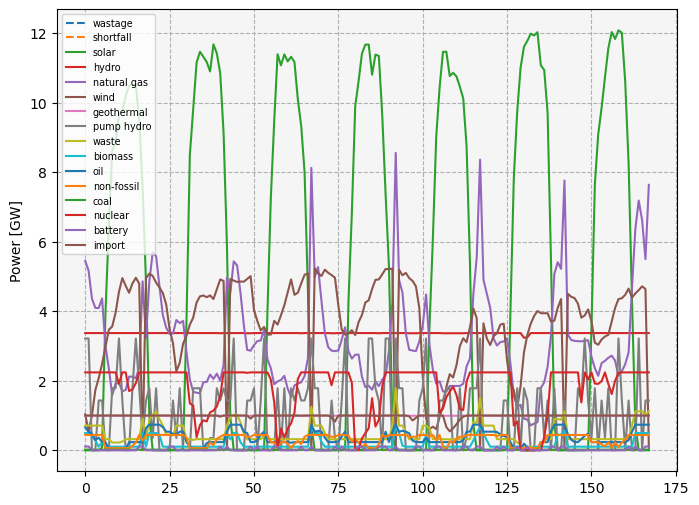

In [24]:
gen_amounts = {'wastage': [], 'shortfall': []}

for source, node in graph._node.items():

    gen_amounts['wastage'].append(network.results[source]['wastage'])
    gen_amounts['shortfall'].append(network.results[source]['shortfall'])

for source, node in graph._node.items():

    for asset in node['assets']:

        if 'fuel' not in asset:

            continue

        if asset['fuel'] not in gen_amounts:

            gen_amounts[asset['fuel']] = (
                [network.results[source]['assets'][asset['id']]['net']]
            )

        else:

            gen_amounts[asset['fuel']].append(
                [network.results[source]['assets'][asset['id']]['net']]
            )

for key, val in gen_amounts.items():

    gen_amounts[key] = np.vstack(val).sum(axis = 0) / 1e9

fig, ax = plt.subplots(figsize = (8, 6))

for key, val in gen_amounts.items():

    ax.plot(
        np.abs(val),
        label = key,
        ls = '--' if key in ['wastage', 'shortfall'] else None,
    )

kw = {
    'facecolor': 'whitesmoke',
    'ylabel': 'Power [GW]',
}

_ = ax.set(**kw)

kw = {
    'ls': '--',
}

_ = ax.grid(**kw)

kw = {
    'fontsize': 'x-small',
}

_ = ax.legend(**kw)

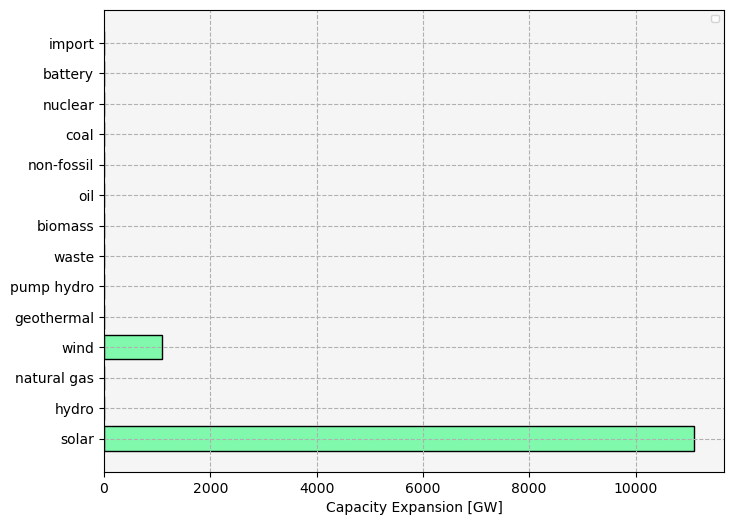

In [47]:
capex_amounts = {}

for source, node in graph._node.items():

    for asset in node['assets']:

        if 'fuel' not in asset:

            continue

        if asset['fuel'] not in capex_amounts:

            capex_amounts[asset['fuel']] = (
                [network.results[source]['assets'][asset['id']]['capex']]
            )

        else:

            capex_amounts[asset['fuel']].append(
                [network.results[source]['assets'][asset['id']]['capex']]
            )

for key, val in capex_amounts.items():

    capex_amounts[key] = np.vstack(val).sum(axis = 0)[0] / 1e6

fig, ax = plt.subplots(figsize = (8, 6))

kw = {
    'color': 'xkcd:seafoam',
    'ec': 'k',
}

ax.barh(list(capex_amounts.keys()), list(capex_amounts.values()), **kw)

kw = {
    'facecolor': 'whitesmoke',
    'xlabel': 'Capacity Expansion [GW]',
}

_ = ax.set(**kw)

kw = {
    'ls': '--',
}

_ = ax.grid(**kw)

kw = {
    'fontsize': 'x-small',
}

_ = ax.legend(**kw)